In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("outputs/data_info/train.csv", index_col=0)
val_df = pd.read_csv("outputs/data_info/val.csv", index_col=0)
test_df = pd.read_csv("outputs/data_info/test.csv", index_col=0)

combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
combined_df.to_csv("outputs/data_info/combined_df.csv")

combined_df.head()

,files,subject,labels,infos,game,session
0,Participants_12_FS_638684957958403318_0_emotio...,Participants_12_FS,ENGAGED,0.5,color_words,638684957958403318
1,Participants_12_FS_638684957958403318_1_emotio...,Participants_12_FS,ENGAGED,0.5,color_words,638684957958403318
2,Participants_12_FS_638684957958403318_2_emotio...,Participants_12_FS,ENGAGED,0.5,color_words,638684957958403318
3,Participants_12_FS_638684957958403318_3_emotio...,Participants_12_FS,ENGAGED,0.5,color_words,638684957958403318
4,Participants_12_FS_638684957958403318_4_emotio...,Participants_12_FS,ENGAGED,0.5,color_words,638684957958403318


# Training Labels

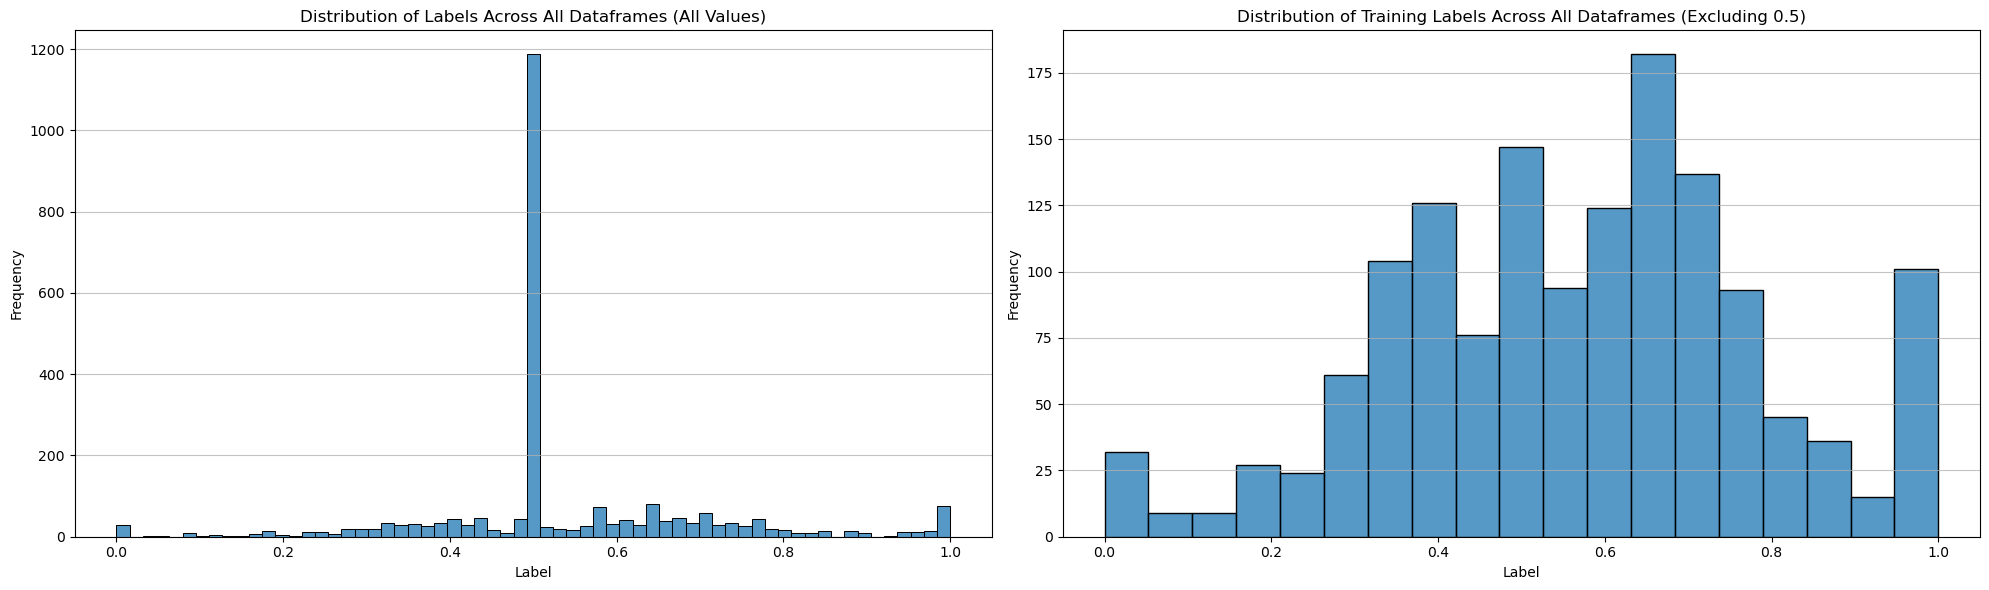

In [3]:
# Distribution of labels
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# First subplot
sns.histplot(combined_df['infos'], kde=False, ax=axes[0])
axes[0].set_title('Distribution of Labels Across All Dataframes (All Values)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.75)

# Second subplot
combined_df_no05 = combined_df[combined_df['infos'] != 0.5]
combined_df_no05 = combined_df_no05[combined_df_no05['infos'] != 0.5000001]
sns.histplot(combined_df_no05['infos'], kde=False, ax=axes[1])
axes[1].set_title('Distribution of Training Labels Across All Dataframes (Excluding 0.5)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [7]:
combined_df_no05.game.value_counts()

game
canvas_painter    681
tower_of_hanoi    295
color_words       252
cube_stacking     214
Name: count, dtype: int64

Comparison boxplots saved as 'outputs/labels_boxplot_by_game_comparison.png'


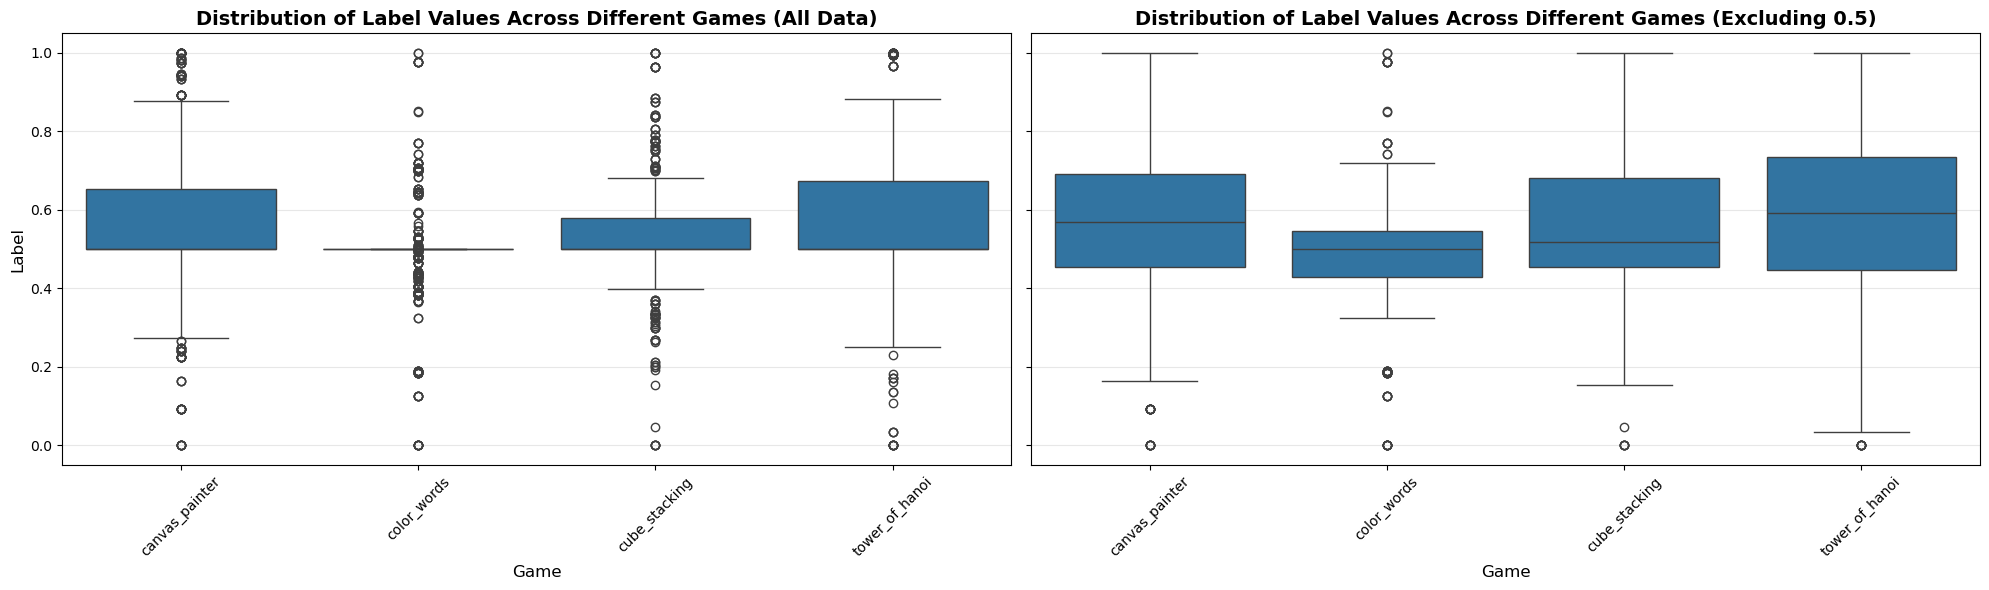

In [38]:
# Distribution of labels by game
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

combined_df = combined_df.sort_values(by='game')
combined_df_no05 = combined_df[combined_df['infos'] != 0.5]

# Plot for combined_df
sns.boxplot(data=combined_df, x='game', y='infos', ax=axes[0])
axes[0].set_title('Distribution of Label Values Across Different Games (All Data)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Game', fontsize=12)
axes[0].set_ylabel('Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot for combined_df_no05
sns.boxplot(data=combined_df_no05, x='game', y='infos', ax=axes[1])
axes[1].set_title('Distribution of Label Values Across Different Games (Excluding 0.5)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Game', fontsize=12)
axes[1].set_ylabel('') # Share y-axis, so no need for a label on the second plot
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/labels_boxplot_by_game_comparison.png', dpi=300, bbox_inches='tight')
print("Comparison boxplots saved as 'outputs/labels_boxplot_by_game_comparison.png'")
plt.show()

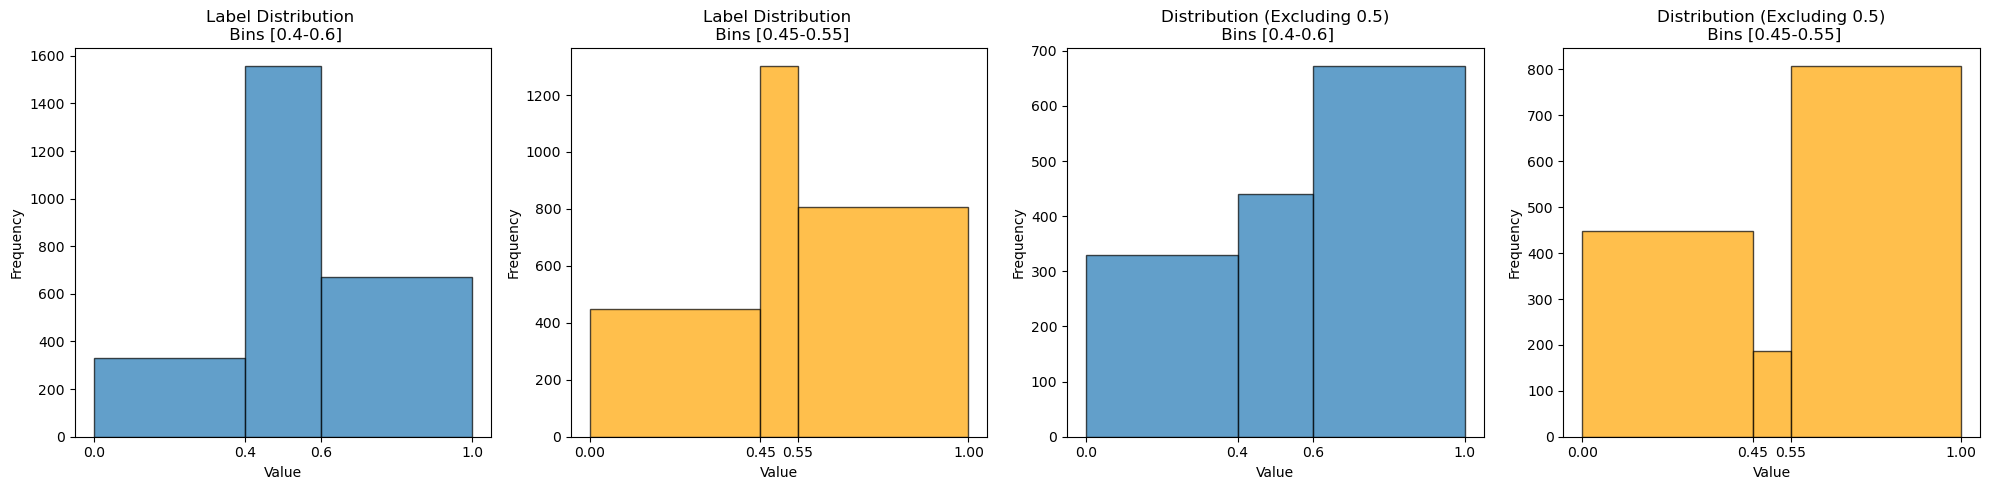

In [37]:
import matplotlib.pyplot as plt

borders_1 = [0, 0.4, 0.6, 1.0]
borders_2 = [0, 0.45, 0.55, 1.0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# First histogram borders
axes[0].hist(combined_df['infos'], bins=borders_1, edgecolor='black', alpha=0.7)
axes[0].set_title(f"Label Distribution \n Bins [{borders_1[1]}-{borders_1[2]}]")
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(borders_1)

# Second histogram borders
axes[1].hist(combined_df['infos'], bins=borders_2, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f"Label Distribution \n Bins [{borders_2[1]}-{borders_2[2]}]")
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(borders_2)

# First histogram borders
axes[2].hist(combined_df_no05['infos'], bins=borders_1, edgecolor='black', alpha=0.7)
axes[2].set_title(f"Distribution (Excluding 0.5)\n Bins [{borders_1[1]}-{borders_1[2]}]")
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')
axes[2].set_xticks(borders_1)

# Second histogram borders
axes[3].hist(combined_df_no05['infos'], bins=borders_2, edgecolor='black', alpha=0.7, color='orange')
axes[3].set_title(f"Distribution (Excluding 0.5)\n Bins [{borders_2[1]}-{borders_2[2]}]")
axes[3].set_xlabel('Value')
axes[3].set_ylabel('Frequency')
axes[3].set_xticks(borders_2)

plt.tight_layout()
plt.show()


In [26]:
combined_df[(combined_df["game"]=="color_words") & (combined_df["subject"]=="Participant_13_L")]

,files,subject,labels,infos,game,session
2371,Participant_13_L_638687316793612861_0_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2372,Participant_13_L_638687316793612861_1_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2373,Participant_13_L_638687316793612861_2_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2374,Participant_13_L_638687316793612861_3_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2375,Participant_13_L_638687316793612861_4_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2376,Participant_13_L_638687316793612861_5_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2377,Participant_13_L_638687316793612861_6_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2378,Participant_13_L_638687316793612861_7_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2379,Participant_13_L_638687316793612861_8_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2380,Participant_13_L_638687325033272905_0_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687325033272905


In [27]:
combined_df_no_dup[(combined_df_no_dup["game"]=="color_words") & (combined_df_no_dup["subject"]=="Participant_13_L")]

,files,subject,labels,infos,game,session
2371,Participant_13_L_638687316793612861_0_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687316793612861
2380,Participant_13_L_638687325033272905_0_emotion_...,Participant_13_L,ENGAGED,0.500000,color_words,638687325033272905
2384,Participant_13_L_638687325033272905_4_emotion_...,Participant_13_L,BORED,0.387102,color_words,638687325033272905
2388,Participant_13_L_638687325033272905_8_emotion_...,Participant_13_L,BORED,0.368854,color_words,638687325033272905


In [ ]:
combined_df_no_dup = combined_df.copy()
combined_df_no_dup.drop_duplicates(subset=['subject', 'labels', 'infos', 'game', 'session'], inplace=True)

print(combined_df.shape)
print(combined_df_no_dup.shape)

combined_df_no_dup.to_csv('outputs/data_info/combined_df_no_dup.csv', index=False)
combined_df_no_dup.head()

(2557, 6)
(505, 6)


,files,subject,labels,infos,game,session
0,Participants_12_FS_638684957958403318_0_emotio...,Participants_12_FS,ENGAGED,0.500000,color_words,638684957958403318
20,Participants_12_FS_638684945320524455_0_emotio...,Participants_12_FS,ENGAGED,0.500000,color_words,638684945320524455
28,Participants_12_FS_638684943237742917_0_emotio...,Participants_12_FS,ENGAGED,0.500000,tower_of_hanoi,638684943237742917
31,Participants_12_FS_638684943237742917_3_emotio...,Participants_12_FS,ENGAGED,0.514778,tower_of_hanoi,638684943237742917
32,Participants_12_FS_638684943237742917_4_emotio...,Participants_12_FS,FRUSTRATED,0.645684,tower_of_hanoi,638684943237742917


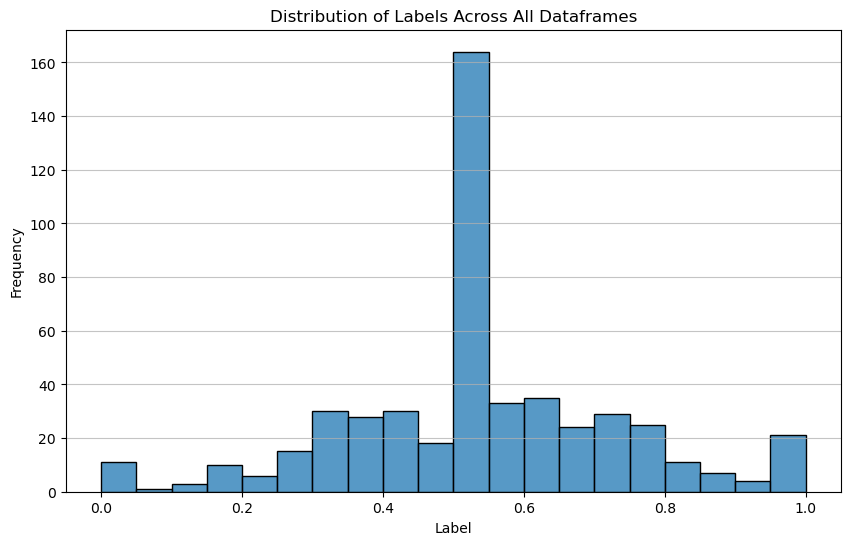

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df_no_dup['infos'], kde=False)
plt.title('Distribution of Labels Across All Dataframes')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [14]:
print(f"Number of < 0.1 instances: {combined_df[combined_df['infos'] < 0.1].shape[0]}")
print(f"Number of = 0.5 instances: {combined_df[combined_df['infos'] == 0.5].shape[0]}")
print(f"Number of > 0.9 instances: {combined_df[combined_df['infos'] > 0.9].shape[0]}")

Number of < 0.1 instances: 41
Number of = 0.5 instances: 848
Number of > 0.9 instances: 116
